# Motor data quality and policy-level actuarial benchmark

**Authors:** Elia Batako and Manuel Ntumba  
**Framework:** ARCCRAFT  
**Status:** retrospective exploratory benchmark

## TL;DR

This notebook audits the complete 47-field motor schema and evaluates three matched forecast specifications over the 2022→2023 and 2022–2023→2024 temporal origins. Policy-level frequency improves held-out Poisson deviance in both years, but it does not improve every aggregate error and all models miss the 2024 claim-count process interval. Policy-level severity is not consistently superior: it materially worsens the 2023 aggregate incurred error and remains miscalibrated across risk deciles. The evidence therefore supports differentiated risk ranking, not general predictive superiority or complete validation. Because both 2024 and one implementation prototype were inspected before this final run, the exercise is retrospective rather than preregistered or confirmatory.

## 1. Context and methods

The analysis follows `16_RETROSPECTIVE_ANALYSIS_SPECIFICATION.md`. It compares:

- **B0 — aggregate pooled mean:** pooled claim frequency and incurred loss per reported claim;
- **B1 — policy frequency / pooled severity:** policy-level frequency differentiation with pooled severity;
- **B2 — policy frequency / policy severity:** policy-level frequency and cost-per-reported-claim differentiation.

Both policy models use penalized Poisson pseudo-maximum likelihood implemented with a sparse design matrix and L-BFGS-B. The cost model admits zero-incurred claim rows and is interpreted as a conditional mean model, not a literal Poisson model for currency.

### Key assumptions

- Target-year policy characteristics and exposure are assumed known at forecast inception.
- Cancellation status is excluded because it may contain post-inception information.
- `age_driving_licence` is used only as an unidentified numeric proxy because its documented meaning conflicts with its observed range.
- Aggregate process intervals exclude parameter uncertainty and inherit the lognormal-severity dispersion proxy already used by the external motor experiment.
- Two evaluation years cannot establish stable coverage, tail calibration, or external validity.

In [1]:
from pathlib import Path
import hashlib, json, sqlite3, subprocess, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
OUT = REPO.parents[1] / "ARCCRAFT"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(OUT))

from backend.data_service import empirical_motor_calibration
from policy_benchmark_core import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, fit_policy_models, load_model_data,
)

DB = REPO / "data" / "platform.db"
DICTIONARY = REPO / "data" / "raw" / "motor_variables.csv"
CORE = OUT / "policy_benchmark_core.py"
SPEC = OUT / "16_RETROSPECTIVE_ANALYSIS_SPECIFICATION.md"

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data provenance and schema

In [2]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO, text=True).strip()
git_diff = subprocess.check_output(["git", "diff", "--binary"], cwd=REPO)

with sqlite3.connect(DB) as con:
    integrity = con.execute("PRAGMA integrity_check").fetchone()[0]
    schema = pd.read_sql_query("PRAGMA table_info(motor_portfolio)", con)

dictionary = pd.read_csv(DICTIONARY)
documented_variables = set(dictionary["Variables"].dropna().astype(str))
database_variables = set(schema["name"].astype(str))

provenance = pd.DataFrame({
    "item": ["database_sha256", "dictionary_sha256", "model_core_sha256", "analysis_spec_sha256",
             "git_commit", "working_diff_sha256", "sqlite_integrity", "database_columns"],
    "value": [sha256(DB), sha256(DICTIONARY), sha256(CORE), sha256(SPEC), git_commit,
              hashlib.sha256(git_diff).hexdigest(), integrity, len(database_variables)],
})
schema_check = pd.DataFrame({
    "check": ["documented_not_in_database", "database_not_in_dictionary"],
    "values": [sorted(documented_variables - database_variables), sorted(database_variables - documented_variables)],
})
display(provenance)
display(schema_check)
assert integrity == "ok" and documented_variables == database_variables and len(database_variables) == 47

,item,value
0,database_sha256,c2bf54460e0613c7ad12eab7d0169ffc4259e121ae3ce8...
1,dictionary_sha256,cf27ebbce9077e3d1eadc6e384668e361af10b94462f8b...
2,model_core_sha256,561fd6e238a419f71db0190581c28fcc9be9ae383a382f...
3,analysis_spec_sha256,8dddc281216787b1c08087d3f71182df1950cb6a8b061e...
4,git_commit,b3df670227efa4aecf5383979b90f3eab15ae528
5,working_diff_sha256,7aaa30050600434d7695244574bae9a859084c633d0464...
6,sqlite_integrity,ok
7,database_columns,47


,check,values
0,documented_not_in_database,[]
1,database_not_in_dictionary,[]


## 3. Completeness, uniqueness, validity, and reconciliation

In [3]:
text_columns = schema.loc[schema.type.str.upper() == "TEXT", "name"].tolist()
all_columns = schema.name.tolist()

with sqlite3.connect(DB) as con:
    row_count = con.execute("SELECT COUNT(*) FROM motor_portfolio").fetchone()[0]
    null_rows = []
    for column in all_columns:
        nulls = con.execute(f'SELECT SUM("{column}" IS NULL) FROM motor_portfolio').fetchone()[0] or 0
        null_rows.append({"column": column, "null_count": int(nulls), "null_rate": nulls / row_count})
    missingness = pd.DataFrame(null_rows).sort_values(["null_count", "column"], ascending=[False, True])

    exact_duplicates = con.execute('''
        SELECT COUNT(*) FROM (
          SELECT *, COUNT(*) n FROM motor_portfolio
          GROUP BY insured_id, year, policy_type, policy_status, business_type, payment_frequency,
                   bonus_score, driver_age, vehicle_age, age_driving_licence, fuel_type, vehicle_value,
                   seats, power_to_weight_ratio, vehicle_brand, municipality_type, circulation_area,
                   total_premium, liability_premium, property_damage_premium, theft_premium,
                   fire_premium, glass_premium, legal_protection_premium, occupants_premium,
                   total_claims, liability_claims, liability_property_claims, liability_injury_claims,
                   property_claims, theft_claims, fire_claims, glass_claims, legal_protection_claims,
                   occupants_claims, total_incurred, liability_incurred, liability_property_incurred,
                   liability_injury_incurred, property_incurred, theft_incurred, fire_incurred,
                   glass_incurred, legal_protection_incurred, occupants_incurred,
                   total_exposure, liability_exposure HAVING n > 1
        )
    ''').fetchone()[0]
    key_duplicates = con.execute('''
        SELECT COUNT(*) FROM (
          SELECT insured_id, year, COUNT(*) n FROM motor_portfolio
          GROUP BY insured_id, year HAVING n > 1
        )
    ''').fetchone()[0]

    rule_values = con.execute('''
        SELECT
          SUM(total_exposure = 0),
          SUM(total_exposure = 0 AND total_claims > 0),
          SUM(total_exposure = 0 AND total_premium > 0),
          SUM(total_claims = 0 AND total_incurred > 0),
          SUM(total_claims > 0 AND total_incurred = 0),
          SUM(total_claims > 0),
          SUM(total_premium = 0),
          SUM(ABS(total_premium - (liability_premium + property_damage_premium + theft_premium + fire_premium + glass_premium + legal_protection_premium + occupants_premium)) > 0.01),
          SUM(total_claims != liability_claims + property_claims + theft_claims + fire_claims + glass_claims + legal_protection_claims + occupants_claims),
          SUM(ABS(total_incurred - (liability_incurred + property_incurred + theft_incurred + fire_incurred + glass_incurred + legal_protection_incurred + occupants_incurred)) > 0.01)
        FROM motor_portfolio
    ''').fetchone()

rule_names = [
    "zero exposure", "zero exposure with claims", "zero exposure with positive premium",
    "zero claims with positive incurred", "positive claims with zero incurred", "rows with positive claims",
    "zero premium", "premium total mismatch > 0.01", "claim total mismatch", "incurred total mismatch > 0.01",
]
rule_checks = pd.DataFrame({"rule": rule_names, "rows": rule_values})
display(missingness.head(12))
display(pd.DataFrame([{"rows": row_count, "exact_duplicate_groups": exact_duplicates,
                       "duplicate_insured_year_keys": key_duplicates}]))
display(rule_checks)

,column,null_count,null_rate
11,vehicle_value,513,0.001449
9,age_driving_licence,2,0.000006
8,vehicle_age,2,0.000006
6,bonus_score,0,0.000000
4,business_type,0,0.000000
16,circulation_area,0,0.000000
7,driver_age,0,0.000000
31,fire_claims,0,0.000000
41,fire_incurred,0,0.000000
21,fire_premium,0,0.000000


,rows,exact_duplicate_groups,duplicate_insured_year_keys
0,354140,0,0


,rule,rows
0,zero exposure,49
1,zero exposure with claims,1
2,zero exposure with positive premium,0
3,zero claims with positive incurred,0
4,positive claims with zero incurred,8543
5,rows with positive claims,50807
6,zero premium,49
7,premium total mismatch > 0.01,0
8,claim total mismatch,0
9,incurred total mismatch > 0.01,0


In [4]:
model_data = load_model_data(DB)

numeric_profile_rows = []
for column in NUMERIC_FEATURES + ["total_premium", "total_claims", "total_incurred", "total_exposure"]:
    values = pd.to_numeric(model_data[column], errors="coerce")
    quantiles = values.quantile([0, .005, .01, .5, .99, .995, 1])
    numeric_profile_rows.append({
        "column": column, "min": quantiles.loc[0], "q005": quantiles.loc[.005],
        "q01": quantiles.loc[.01], "median": quantiles.loc[.5], "q99": quantiles.loc[.99],
        "q995": quantiles.loc[.995], "max": quantiles.loc[1],
    })
numeric_profile = pd.DataFrame(numeric_profile_rows)

category_rows = []
for column in CATEGORICAL_FEATURES + ["policy_status"]:
    values = model_data[column].fillna("__NULL__").astype(str).str.strip()
    counts = values.value_counts()
    category_rows.append({
        "column": column, "levels": counts.size, "top_level": counts.index[0],
        "top_share": counts.iloc[0] / len(values),
        "blank_count": int((values == "").sum()),
        "na_sentinel_count": int(values.str.upper().isin(["NA", "N/A", "UNKNOWN", "UNK"]).sum()),
    })
category_profile = pd.DataFrame(category_rows)
display(numeric_profile)
display(category_profile)

,column,min,q005,q01,median,q99,q995,max
0,driver_age,18.000000,25.000000,27.000000,48.000000,75.000000,77.000000,90.000000
1,vehicle_age,0.000000,3.000000,4.000000,25.000000,51.000000,52.000000,68.000000
2,age_driving_licence,0.000000,18.000000,18.000000,20.000000,48.000000,51.000000,80.000000
3,vehicle_value,"1,630.125000","9,251.865000","10,160.110275","24,729.600000","71,121.750000","81,413.272500","374,034.209850"
4,seats,2.000000,2.000000,2.000000,5.000000,7.000000,8.000000,9.000000
5,power_to_weight_ratio,0.000000,6.510000,7.030000,12.050000,19.000000,20.250000,64.810000
6,total_premium,0.000000,3.657385,6.719767,257.903122,"1,086.903350","1,315.778603","5,107.639865"
7,total_claims,0.000000,0.000000,0.000000,0.000000,3.000000,4.000000,18.000000
8,total_incurred,0.000000,0.000000,0.000000,0.000000,"3,784.281195","6,424.036300","571,128.318000"
9,total_exposure,0.000000,0.010959,0.019178,0.838356,1.000000,1.000000,1.000000


,column,levels,top_level,top_share,blank_count,na_sentinel_count
0,policy_type,5,CC,0.577839,0,0
1,business_type,2,NB,0.693051,0,0
2,payment_frequency,3,A,0.812947,0,0
3,bonus_score,3,G,0.964475,0,0
4,fuel_type,3,D,0.639301,0,1287
5,vehicle_brand,68,RENAULT,0.097007,0,0
6,municipality_type,3,I,0.645555,0,0
7,circulation_area,2,U,0.537945,0,0
8,policy_status,2,A,0.891772,0,0


## 4. Temporal coverage and portfolio shift

,year,policy_rows,insureds,exposure,premium,claims,incurred,claim_frequency,loss_ratio
0,2022,67172,67172,"41,912.495890","18,697,928.342009",12665,"12,270,105.055000",0.302177,0.656228
1,2023,118835,118835,"82,399.038356","35,344,308.084516",25158,"23,488,354.354000",0.305319,0.664558
2,2024,168133,168133,"126,014.364384","51,037,433.000661",39276,"38,106,351.280000",0.311679,0.746635


,year,returning_from_prior_year,share_of_current_insureds
0,2023,63107,0.531047
1,2024,105355,0.626617


,column,largest_level,max_share_range_pp
1,business_type,NB,40.568626
8,policy_status,A,6.311502
2,payment_frequency,A,5.931597
0,policy_type,COMP_E,3.460281
3,bonus_score,G,2.030725
6,municipality_type,I,1.723695
4,fuel_type,G,0.850197
5,vehicle_brand,BMW,0.458310
7,circulation_area,R,0.185549


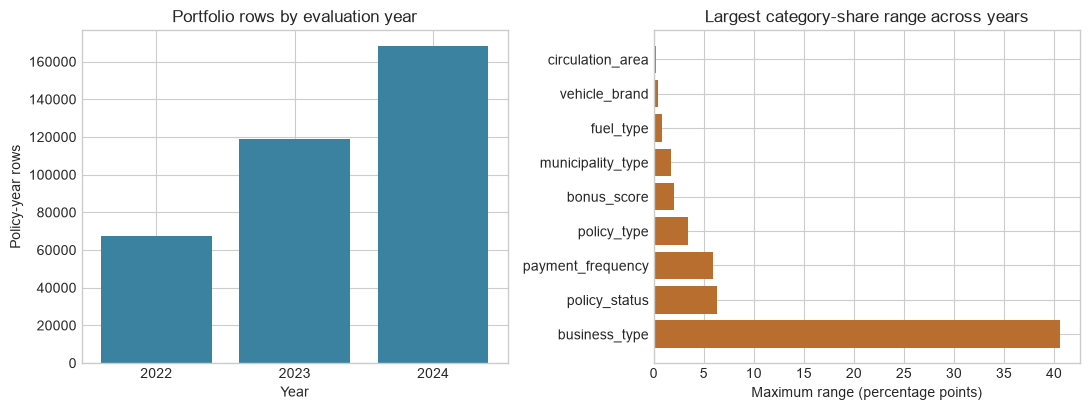

In [5]:
annual = model_data.groupby("year", as_index=False).agg(
    policy_rows=("insured_id", "size"), insureds=("insured_id", "nunique"),
    exposure=("total_exposure", "sum"), premium=("total_premium", "sum"),
    claims=("total_claims", "sum"), incurred=("total_incurred", "sum"),
)
annual["claim_frequency"] = annual.claims / annual.exposure
annual["loss_ratio"] = annual.incurred / annual.premium

id_sets = {year: set(model_data.loc[model_data.year == year, "insured_id"]) for year in sorted(model_data.year.unique())}
returning = []
for year in [2023, 2024]:
    overlap = len(id_sets[year] & id_sets[year - 1])
    returning.append({"year": year, "returning_from_prior_year": overlap,
                      "share_of_current_insureds": overlap / len(id_sets[year])})
returning = pd.DataFrame(returning)

shift_rows = []
for column in CATEGORICAL_FEATURES + ["policy_status"]:
    shares = pd.crosstab(model_data.year, model_data[column], normalize="index")
    max_shift = float((shares.max(axis=0) - shares.min(axis=0)).max())
    level = (shares.max(axis=0) - shares.min(axis=0)).idxmax()
    shift_rows.append({"column": column, "largest_level": level, "max_share_range_pp": 100 * max_shift})
category_shift = pd.DataFrame(shift_rows).sort_values("max_share_range_pp", ascending=False)

display(annual)
display(returning)
display(category_shift)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(annual.year.astype(str), annual.policy_rows, color="#3b82a0")
axes[0].set(title="Portfolio rows by evaluation year", xlabel="Year", ylabel="Policy-year rows")
axes[1].barh(category_shift.column, category_shift.max_share_range_pp, color="#b76e2f")
axes[1].set(title="Largest category-share range across years", xlabel="Maximum range (percentage points)")
fig.tight_layout()
fig.savefig(FIG / "data_quality_temporal_shift.png", dpi=180, bbox_inches="tight")
plt.show()

In [6]:
zero_cost_claim_rows = int(rule_checks.loc[rule_checks.rule == "positive claims with zero incurred", "rows"].iloc[0])
claim_rows = int(rule_checks.loc[rule_checks.rule == "rows with positive claims", "rows"].iloc[0])
quality_findings = pd.DataFrame([
    {"finding": "Licence field semantic conflict", "evidence": "Dictionary says calendar year; observed range is 0 to 80", "severity": "high", "confidence": "high", "model_action": "Use only as an unidentified numeric proxy"},
    {"finding": "Claim rows with zero incurred", "evidence": f"{zero_cost_claim_rows:,} of {claim_rows:,} claim-bearing rows ({zero_cost_claim_rows/claim_rows:.2%})", "severity": "high", "confidence": "high", "model_action": "Use non-negative pseudo-likelihood; do not fit positive-only Gamma severity"},
    {"finding": "Zero exposure with claims", "evidence": f"{int(rule_values[1])} row", "severity": "medium", "confidence": "high", "model_action": "Exclude from frequency-offset fitting and retain in audit"},
    {"finding": "Missing vehicle attributes", "evidence": "513 vehicle values; 2 vehicle ages; 2 licence values", "severity": "low", "confidence": "high", "model_action": "Calibration-period median imputation"},
    {"finding": "Fuel sentinel outside documented values", "evidence": f"{int(category_profile.loc[category_profile.column == 'fuel_type', 'na_sentinel_count'].iloc[0]):,} rows coded NA", "severity": "medium", "confidence": "high", "model_action": "Retain as explicit category; request source definition"},
    {"finding": "Cancellation leakage risk", "evidence": "Policy status is active/cancelled at analysis time", "severity": "high", "confidence": "medium", "model_action": "Exclude policy_status from predictors"},
    {"finding": "Strong temporal portfolio growth", "evidence": f"Rows rise from {annual.policy_rows.iloc[0]:,} to {annual.policy_rows.iloc[-1]:,}", "severity": "high", "confidence": "high", "model_action": "Use temporal origins and condition on target portfolio"},
    {"finding": "Totals reconcile to components", "evidence": "0 premium, claim-count, or incurred mismatches at defined tolerance", "severity": "pass", "confidence": "high", "model_action": "No repair"},
    {"finding": "Insured-year grain is unique", "evidence": "0 duplicate insured-year keys and 0 exact duplicate groups", "severity": "pass", "confidence": "high", "model_action": "Use insured-year as analysis grain"},
])
display(quality_findings)

,finding,evidence,severity,confidence,model_action
0,Licence field semantic conflict,Dictionary says calendar year; observed range ...,high,high,Use only as an unidentified numeric proxy
1,Claim rows with zero incurred,"8,543 of 50,807 claim-bearing rows (16.81%)",high,high,Use non-negative pseudo-likelihood; do not fit...
2,Zero exposure with claims,1 row,medium,high,Exclude from frequency-offset fitting and reta...
3,Missing vehicle attributes,513 vehicle values; 2 vehicle ages; 2 licence ...,low,high,Calibration-period median imputation
4,Fuel sentinel outside documented values,"1,287 rows coded NA",medium,high,Retain as explicit category; request source de...
5,Cancellation leakage risk,Policy status is active/cancelled at analysis ...,high,medium,Exclude policy_status from predictors
6,Strong temporal portfolio growth,"Rows rise from 67,172 to 168,133",high,high,Use temporal origins and condition on target p...
7,Totals reconcile to components,"0 premium, claim-count, or incurred mismatches...",pass,high,No repair
8,Insured-year grain is unique,0 duplicate insured-year keys and 0 exact dupl...,pass,high,Use insured-year as analysis grain


## 5. Policy-level temporal benchmark

In [7]:
sigma_2022 = float(empirical_motor_calibration(2022, 2022)["severity_proxy"]["sigma_log"] or 0.0)
sigma_2022_23 = float(empirical_motor_calibration(2022, 2023)["severity_proxy"]["sigma_log"] or 0.0)

results_2023, calibration_2023, diagnostics_2023 = fit_policy_models(
    model_data, [2022], 2023, sigma_2022
)
results_2024, calibration_2024, diagnostics_2024 = fit_policy_models(
    model_data, [2022, 2023], 2024, sigma_2022_23
)
model_results = pd.concat([results_2023, results_2024], ignore_index=True)
decile_calibration = pd.concat([calibration_2023, calibration_2024], ignore_index=True)

def compact_diagnostics(target, diagnostics):
    return {
        "target": target,
        "n_features": diagnostics["n_features"],
        "frequency_converged": diagnostics["frequency_converged"],
        "frequency_iterations": diagnostics["frequency_iterations"],
        "frequency_training_total_ratio": diagnostics["frequency_training_predicted"] / diagnostics["frequency_training_observed"],
        "severity_converged": diagnostics["severity_converged"],
        "severity_iterations": diagnostics["severity_iterations"],
        "severity_training_total_ratio": diagnostics["severity_training_predicted"] / diagnostics["severity_training_observed"],
        "frequency_message": diagnostics["frequency_message"],
        "severity_message": diagnostics["severity_message"],
    }

model_diagnostics = pd.DataFrame([
    compact_diagnostics(2023, diagnostics_2023),
    compact_diagnostics(2024, diagnostics_2024),
])
display(model_results[[
    "target", "model", "claim_error_pct", "claim_poisson_deviance",
    "claims_in_process_95_interval", "incurred_error_pct", "incurred_poisson_deviance",
    "incurred_in_process_95_interval",
]])
display(model_diagnostics)

,target,model,claim_error_pct,claim_poisson_deviance,claims_in_process_95_interval,incurred_error_pct,incurred_poisson_deviance,incurred_in_process_95_interval
0,2023,aggregate_pooled,-1.029059,0.848075,True,2.700914,"1,200.079780",False
1,2023,policy_frequency_pooled_severity,-0.862588,0.787139,True,2.873659,"1,150.354040",False
2,2023,policy_frequency_policy_severity,-0.862588,0.787139,True,9.579415,"1,174.042548",False
3,2024,aggregate_pooled,-2.380327,0.915317,False,-4.876010,"1,353.535893",False
4,2024,policy_frequency_pooled_severity,-2.428217,0.833038,False,-4.922675,"1,296.257443",False
5,2024,policy_frequency_policy_severity,-2.428217,0.833038,False,-4.443446,"1,302.422205",False


,target,n_features,frequency_converged,frequency_iterations,frequency_training_total_ratio,severity_converged,severity_iterations,severity_training_total_ratio,frequency_message,severity_message
0,2023,54,True,161,1.000000,True,192,1.000000,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,2024,63,True,182,0.999999,True,279,1.000000,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


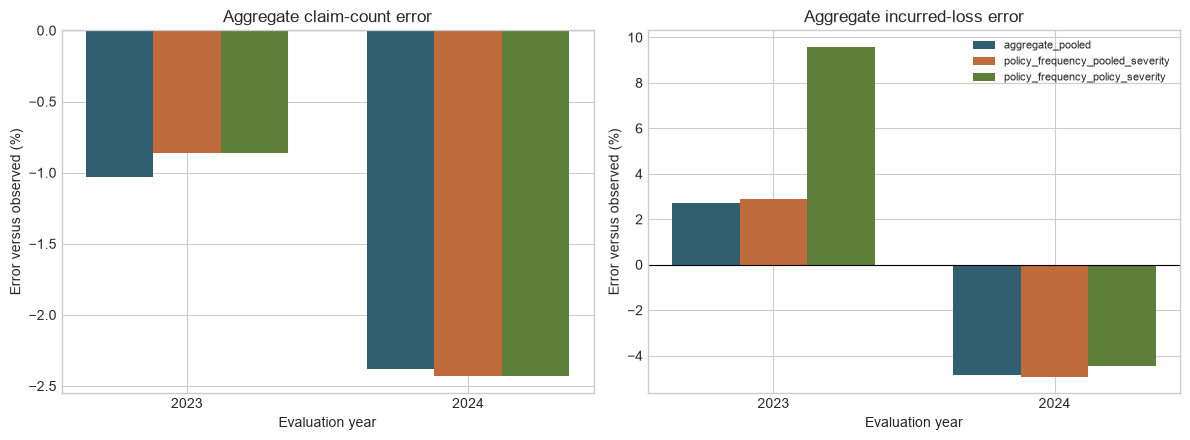

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
models = model_results.model.unique().tolist()
colors = ["#315f72", "#bf6b3b", "#5d7f3a"]
for axis, metric, title in [
    (axes[0], "claim_error_pct", "Aggregate claim-count error"),
    (axes[1], "incurred_error_pct", "Aggregate incurred-loss error"),
]:
    width = 0.24
    x = np.arange(2)
    for j, model in enumerate(models):
        values = model_results.loc[model_results.model == model].sort_values("target")[metric].to_numpy()
        axis.bar(x + (j - 1) * width, values, width, label=model, color=colors[j])
    axis.axhline(0, color="black", lw=0.8)
    axis.set_xticks(x, ["2023", "2024"])
    axis.set(title=title, xlabel="Evaluation year", ylabel="Error versus observed (%)")
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "policy_benchmark_errors.png", dpi=180, bbox_inches="tight")
plt.show()

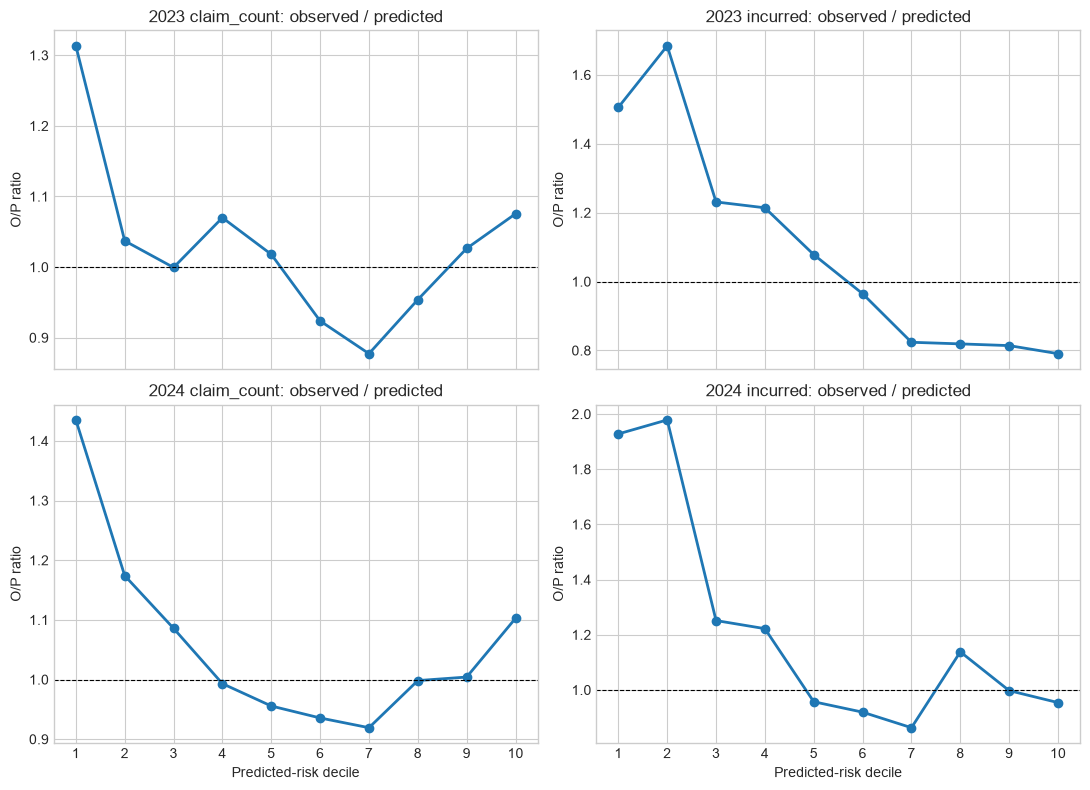

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
for row, target in enumerate([2023, 2024]):
    for col, metric in enumerate(["claim_count", "incurred"]):
        subset = decile_calibration[(decile_calibration.target == target) & (decile_calibration.metric == metric)]
        axes[row, col].plot(subset.decile, subset.observed_to_predicted, marker="o", lw=2)
        axes[row, col].axhline(1, color="black", ls="--", lw=0.8)
        axes[row, col].set(title=f"{target} {metric}: observed / predicted", ylabel="O/P ratio")
        axes[row, col].set_xticks(range(1, 11))
axes[1, 0].set_xlabel("Predicted-risk decile")
axes[1, 1].set_xlabel("Predicted-risk decile")
fig.tight_layout()
fig.savefig(FIG / "policy_benchmark_decile_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Exported evidence

In [10]:
quality_findings.to_csv(OUT / "18_DATA_QUALITY_FINDINGS.csv", index=False)
model_results.to_csv(OUT / "19_POLICY_BENCHMARK_RESULTS.csv", index=False)
decile_calibration.to_csv(OUT / "20_POLICY_DECILE_CALIBRATION.csv", index=False)
model_diagnostics.to_csv(OUT / "21_POLICY_MODEL_DIAGNOSTICS.csv", index=False)
numeric_profile.to_csv(OUT / "22_NUMERIC_PROFILE.csv", index=False)
category_profile.to_csv(OUT / "23_CATEGORY_PROFILE.csv", index=False)
category_shift.to_csv(OUT / "24_TEMPORAL_CATEGORY_SHIFT.csv", index=False)

sorted(p.name for p in OUT.glob("*.csv") if p.name[:2] in {"18", "19", "20", "21", "22", "23", "24"})

['18_DATA_QUALITY_FINDINGS.csv',
 '19_POLICY_BENCHMARK_RESULTS.csv',
 '20_POLICY_DECILE_CALIBRATION.csv',
 '21_POLICY_MODEL_DIAGNOSTICS.csv',
 '22_NUMERIC_PROFILE.csv',
 '23_CATEGORY_PROFILE.csv',
 '24_TEMPORAL_CATEGORY_SHIFT.csv']

## 7. Takeaways

- The database is mechanically consistent at the insured-year grain and its premium, claim-count, and incurred totals reconcile to their defined coverage components.
- Semantic and temporal risks remain material: the licence field is misdescribed or misencoded, cancellation status is unsafe as a predictor, zero-cost claim rows invalidate a naïve positive-only severity model, and portfolio size and composition change sharply over time.
- Policy-level frequency lowers held-out count deviance from 0.8481 to 0.7871 in 2023 and from 0.9153 to 0.8330 in 2024. Its aggregate count error is slightly better in 2023 (-0.86% versus -1.03%) and slightly worse in 2024 (-2.43% versus -2.38%).
- Policy-level severity does not pass a superiority benchmark. Its 2023 aggregate incurred error is +9.58%, compared with +2.70% for the pooled model, and its incurred deviance is worse than the policy-frequency/pooled-severity comparator in both evaluation years.
- Decile diagnostics expose temporal miscalibration: low predicted-risk groups are systematically underpredicted, including count O/P ratios of 1.31 in 2023 and 1.44 in 2024 in the lowest count-risk decile.
- The 2023 claim count falls inside all process-only intervals, but no incurred total does; in 2024 neither observed count nor incurred total is covered by any model's process-only interval.
- The process intervals shown here exclude parameter uncertainty. They are deliberately labelled process-only and cannot support full predictive-calibration claims.
- The full ARCCRAFT procedural grammar remains separate from this empirical motor benchmark. These policy models are matched actuarial comparators, not an empirical validation of the synthetic world generator.